In [ ]:
import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import Dataset, DataLoader, TensorDataset, ConcatDataset

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d

from IPython.display import clear_output
import time
from datetime import datetime, timedelta
import gc

np.random.seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
 # Neural Network
class PINN_Module(nn.Module):

    def __init__(self, model_parameters):
        super(PINN_Module, self).__init__()
        self.Device = model_parameters["Device"]
        self.LowerBounds = model_parameters["LowerBounds"]
        self.UpperBounds = model_parameters["UpperBounds"]
        self.ThermalDiffusivity = model_parameters["ThermalDiffusivity"]
        self.InputDimensions = model_parameters["InputDimensions"]
        self.OutputDimensions = model_parameters["OutputDimensions"]
        self.NumberOfNeurons = model_parameters["NumberOfNeurons"]
        self.NumberOfHiddenLayers = model_parameters["NumberOfHiddenLayers"]
        self.ActivationFunction = model_parameters["ActivationFunction"]
        self.InputLayer = nn.Linear(self.InputDimensions, self.NumberOfNeurons)
        self.HiddenLayers = nn.ModuleList(
            [nn.Linear(self.NumberOfNeurons, self.NumberOfNeurons) for _ in range(self.NumberOfHiddenLayers - 1)])
        self.OutputLayer = nn.Linear(self.NumberOfNeurons, self.OutputDimensions)

        self.init_xavier()


    def forward(self, x):
        lb = self.LowerBounds
        ub = self.UpperBounds
        x = 2*(x - lb)/(ub - lb) - 1
        output = self.ActivationFunction(self.InputLayer(x))
        for k, l in enumerate(self.HiddenLayers):
            output = self.ActivationFunction(l(output))
        output = self.OutputLayer(output)
        return output


    def init_xavier(self):

        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                g = nn.init.calculate_gain('tanh')
                torch.nn.init.xavier_uniform_(m.weight, gain=g)
                # torch.nn.init.xavier_normal_(m.weight, gain=g)
                m.bias.data.fill_(0)

        self.apply(init_weights)


    def internalEnergyBalanceResidue(self, X, T):
        alpha = self.ThermalDiffusivity

        # Compute the derivatives of the output w.r.t. the inputs (space and time) using AD mechanism:
        diff_T = torch.autograd.grad(T, X, create_graph=True, grad_outputs=torch.ones_like(T))[0]
        Tx, Tt = diff_T[:, 0:1], diff_T[:, 1:2]

        # Compute the second derivative of the output w.r.t. the inputs (only space) using AD mechanism:
        Txx = torch.autograd.grad(Tx, X, create_graph=True, grad_outputs=torch.ones_like(T))[0][:, 0:1]

        residue = Tt - alpha*Txx
        return residue

## Problem data

In [ ]:
# Properties of pure solid aluminium
k = 210.0 # W/(m K)
C = 900.0 # J/(kg K)
rho = 2700.0 #kg/m^3
alpha = k/(rho*C)

# Boundaries of space and time domains
ti, tf = 0, 1000.0 # s
xi, xf = 0, 1.0 # m

# Non-dimensionalization
nd = False
if nd:
    tf *= alpha
    alpha = 1

lb = torch.tensor([xi, ti]).to(device)
ub = torch.tensor([xf, tf]).to(device)

# Initial and boundary temperatures
T_ref = 100.
bc_value = bc_value_l = bc_value_r = 300.0/T_ref # K
k1 = np.pi/xf
T_ampl = 100.0/T_ref # K
T0 = lambda x: T_ampl*torch.sin(k1*x) + bc_value # K

## Exact solution

In [ ]:
# Exact solution
T_exact = lambda x, t: T_ampl*np.sin(k1*x)*np.exp(-k1**2*alpha*t) + bc_value

# Grid for evaluation the exact solution
x_test = np.linspace(xi, xf, 1000)
t_test = np.linspace(ti, tf, 1000)
ms_x, ms_t = np.meshgrid(x_test, t_test)
x_test = np.ravel(ms_x).reshape(-1,1)
t_test = np.ravel(ms_t).reshape(-1,1)

T_ex_grid = T_exact(x_test, t_test).reshape(ms_x.shape)

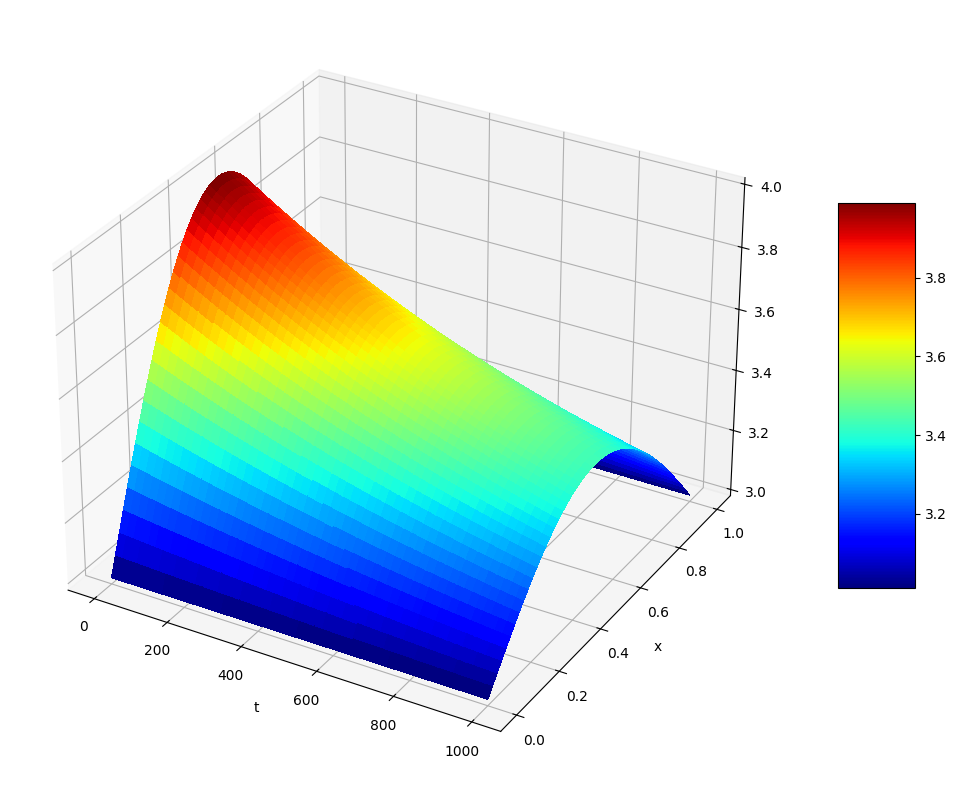

In [ ]:
# Plot the exact temperature distribution
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection = '3d')
#ax.view_init(elev=20, azim=-90)
surf1 = ax.plot_surface(ms_t, ms_x, T_ex_grid, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf1, shrink=0.5, aspect=5)
plt.xlabel('t')
plt.ylabel('x')
plt.show()

## Datasets (collocation points and labelled data points)

In [ ]:
# Generate equispaced tensors for both space and time domains to pick from
x_tensor = torch.linspace(xi, xf, 10000, device=device)
t_tensor = torch.linspace(ti, tf, 10000, device=device)

# Number of collocation points
N_dom = 1000 # Number of collocation points for evaluating the residuals
N_bc = 300 # Number of collocation points for computing the boundary conditions
N_ic = 500 # Number of collocation points for computing the initial condition
N_data = 1000 # Number of labelled data points

# Train, validation and testing sets
tags = ["Domain", "BoundaryConditions", "InitialCondition"]
isData = False # Flag to indicate whether the analysis would use labelled data or not

# Initialize list of dataset objects
ds = []

In [ ]:
## Collocation points for evaluating the residual of the governing PDE

# Generate random collocation points
aux = torch.rand((N_dom, 2), device=device)
X_dom = (lb + (ub - lb)*aux).to(torch.float32)
y_dom = torch.zeros((N_dom, 1), device=device)

ds.append(TensorDataset(X_dom, y_dom))

In [ ]:
## Collocation points for evaluating the boundary and initial conditions

# Generate random collocation points for the left boundary
idx_bc = np.random.choice(t_tensor.size()[0], N_bc, replace=False)
t_bc_l = t_tensor[idx_bc].view(-1, 1)
x_bc_l = xi*torch.ones((N_bc, 1), device=device)
X_bc_l = torch.cat([x_bc_l, t_bc_l], axis=1)
y_bc_l = torch.full((N_bc, 1), bc_value_l)

# Generate random collocation points for the right boundary
idx_bc = np.random.choice(t_tensor.size()[0], N_bc, replace=False)
t_bc_r = t_tensor[idx_bc].view(-1, 1)
x_bc_r = xf*torch.ones((N_bc, 1), device=device)
X_bc_r = torch.cat([x_bc_r, t_bc_r], axis=1)
y_bc_r = torch.full((N_bc, 1), bc_value_r)

# Concatenate the collocation points of both boundaries
X_bc = torch.cat([X_bc_l, X_bc_r], axis=0)
y_bc = torch.cat([y_bc_l, y_bc_r], axis=0)
ds.append(TensorDataset(X_bc, y_bc))

# Generate collocation points for the initial condition
idx_ic = np.random.choice(x_tensor.size()[0], N_ic, replace=False)
x_ic = x_tensor[idx_ic].view(-1, 1)
t_ic = ti*torch.ones((N_ic, 1), device=device)
X_ic = torch.cat([x_ic, t_ic], axis=1)
y_ic = T0(x_ic)
ds.append(TensorDataset(X_ic, y_ic))

In [ ]:
# Generate syntetic temperature labelled data
if isData:
    tags.append("LabelledData")
    idx_data = np.random.choice(x_tensor.size()[0], N_data, replace=False)
    omega = 0.01
    sensor_loc = 0.5
    x_data = torch.full((N_data, 1), sensor_loc, device=device)
    t_data = t_tensor[idx_data].view(-1, 1)
    X_data = torch.cat([x_data, t_data], axis=1)
    exact_temp_data = T_exact(x_data.data.cpu().numpy(), t_data.data.cpu().numpy())
    noisy_temp_data = exact_temp_data + omega*np.max(exact_temp_data)*np.random.normal(size=(N_data, 1))
    y_data = torch.from_numpy(noisy_temp_data).to(torch.float32).to(device)
    ds.append(TensorDataset(X_data, y_data))


In [ ]:
# Dictionary of dataset objects
datasets = dict(zip(tags, ds))

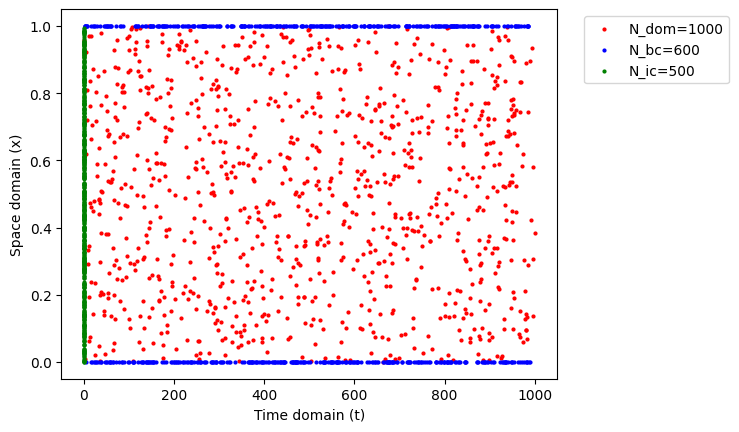

In [ ]:
# Plot the locations of the collocation points in the space-time domain
X_dom_train = (datasets["Domain"][:][0]).data.cpu().numpy()
X_bc_train = (datasets["BoundaryConditions"][:][0]).data.cpu().numpy()
X_ic_train = (datasets["InitialCondition"][:][0]).data.cpu().numpy()
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(X_dom_train[:, 1:2], X_dom_train[0:, 0:1], s=4, c='r', label=f'N_dom={len(X_dom_train)}')
ax.scatter(X_bc_train[:, 1:2], X_bc_train[:, 0:1], s=4, c='b', label=f'N_bc={len(X_bc_train)}')
ax.scatter(X_ic_train[:, 1:2], X_ic_train[:, 0:1], s=4, c='g', label=f'N_ic={len(X_ic_train)}')
if isData:
    X_data_train = (datasets["LabelledData"][:][0]).data.cpu().numpy()
    y_data_train = (datasets["LabelledData"][:][1]).data.cpu().numpy()
    ax.scatter(X_data_train[:, 1:2], X_data_train[:, 0:1], s=4, c='m', label=f'N_Data={len(X_data_train)}', marker='x')
ax.legend()
plt.xlabel('Time domain (t)')
plt.ylabel('Space domain (x)')
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

In [ ]:
if isData:
    fig = plt.figure()
    ax = fig.add_subplot(111)
    t_data = np.linspace(ti, tf, 1000).reshape(-1, 1)
    T_ex = T_exact(np.full((1000, 1), sensor_loc), t_data)
    ax.plot(t_data, T_ex, c='k', label='T. exact')
    ax.scatter(X_data_train[:, 1:2], y_data_train, s=4, c='m', label='T. noisy')
    ax.legend()
    plt.xlabel('Time domain (t)')
    plt.ylabel('Temperature (T)')
    plt.title(f'Temperature at sensor location (x_s={sensor_loc})')
    plt.show()

## Main execution

In [ ]:
# Input dictionary for model instance
model_parameters = {
    "Device": device,
    "LowerBounds": lb.to(device),
    "UpperBounds": ub.to(device),
    "ThermalDiffusivity": alpha,
    "InputDimensions": 2,
    "OutputDimensions": 1,
    "NumberOfNeurons": 20,
    "NumberOfHiddenLayers": 4,
    "ActivationFunction": nn.Tanh()
}

In [ ]:
# Model construction
torch.manual_seed(10)
model = PINN_Module(model_parameters).to(device)

In [ ]:
# Fitting stage
t0 = datetime.now()
data_time_now = datetime.now().strftime("%d%m%Y_%H%M%S")

epochs = 10000
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_train = []
loss_train_dom = []
loss_train_bc = []
loss_train_ic = []
loss_train_data = []
train_keys = ['Overall', 'Domain', 'BC', 'IC', 'Data']
for epoch in range(epochs):
    loss_list = []
    optimizer.zero_grad()
    for tag in tags:
        X = (datasets[tag][:][0]).to(device)
        y = (datasets[tag][:][1]).to(device)
        if tag=='Domain':
            X.requires_grad = True
            T = model(X)
            y_hat = model.internalEnergyBalanceResidue(X, T)
            loss = loss_fn(y_hat, y)
            loss_list.append(loss)

        else:
            T = model(X)
            loss = loss_fn(T, y)
            loss_list.append(loss)

    loss = sum(loss_list)
    loss.backward()
    optimizer.step()

    loss_list.insert(0, loss)
    loss_train.append(loss_list[0].item())
    loss_train_dom.append(loss_list[1].item())
    loss_train_bc.append(loss_list[2].item())
    loss_train_ic.append(loss_list[3].item())
    if isData:
        loss_train_data.append(loss_list[4].item())

    if epoch % 100 == 0:
        log_dict = dict(zip(train_keys, loss_list))
        aux = "".join(f"{key}: {value:.5e}, " for key, value in log_dict.items())
        optimizer_str = type(optimizer).__name__
        print(f"##TRAIN## {optimizer_str} - Epoch: {epoch}, " + aux)

elapsed_time_train = datetime.now() - t0
print("\nTraining Time: ", elapsed_time_train.seconds, "[s]")

##TRAIN## Adam - Epoch: 0, Overall: 1.43688e+01, Domain: 1.31887e-05, BC: 8.57423e+00, IC: 5.79454e+00, 
##TRAIN## Adam - Epoch: 100, Overall: 9.02826e+00, Domain: 3.59944e-05, BC: 7.92438e+00, IC: 1.10384e+00, 
##TRAIN## Adam - Epoch: 200, Overall: 6.67504e+00, Domain: 4.31258e-05, BC: 6.36642e+00, IC: 3.08573e-01, 
##TRAIN## Adam - Epoch: 300, Overall: 4.17561e+00, Domain: 3.76687e-05, BC: 4.03818e+00, IC: 1.37398e-01, 
##TRAIN## Adam - Epoch: 400, Overall: 1.87288e+00, Domain: 2.54545e-05, BC: 1.78985e+00, IC: 8.30007e-02, 
##TRAIN## Adam - Epoch: 500, Overall: 6.82794e-01, Domain: 1.71868e-05, BC: 6.35983e-01, IC: 4.67940e-02, 
##TRAIN## Adam - Epoch: 600, Overall: 2.17778e-01, Domain: 1.31705e-05, BC: 1.93349e-01, IC: 2.44163e-02, 
##TRAIN## Adam - Epoch: 700, Overall: 6.54928e-02, Domain: 1.13560e-05, BC: 5.39522e-02, IC: 1.15292e-02, 
##TRAIN## Adam - Epoch: 800, Overall: 2.21500e-02, Domain: 1.05548e-05, BC: 1.68652e-02, IC: 5.27423e-03, 
##TRAIN## Adam - Epoch: 900, Overall: 1

## Loss functions

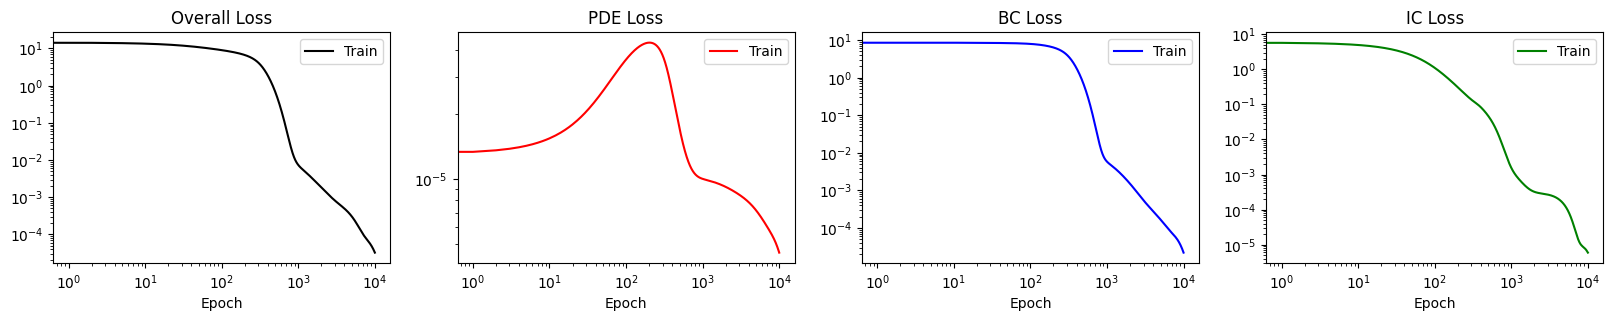

In [ ]:
# Evolution of the loss function
loss_train_list = [loss_train, loss_train_dom, loss_train_bc, loss_train_ic]
colors = ['black', 'red', 'blue', 'green']
titles = ['Overall Loss', 'PDE Loss', 'BC Loss', 'IC Loss']
if isData:
    loss_train_list.append(loss_train_data)
    colors.append('magenta')
    titles.append('Data Loss')

fig, ax = plt.subplots(1, len(loss_train_list), figsize=(20, 3))
for i in range(len(loss_train_list)):
    epochs_train = np.arange(0, len(loss_train_list[i]))
    ax[i].loglog(epochs_train, loss_train_list[i], color=colors[i], label='Train')
    ax[i].set_xlabel('Epoch')
    ax[i].set_title(titles[i])
    ax[i].legend()
plt.show()

## Prediction

In [ ]:
# Definition of tensors from the testing points for evaluating the trained PINN
pt_x = torch.from_numpy(x_test).float()
pt_t = torch.from_numpy(t_test).float()
ms_Tex = T_exact(x_test, t_test).reshape(ms_x.shape)

In [ ]:
# Predicted solution
X_pred = torch.cat([pt_x, pt_t], axis=1).to(device)
Tpred = model(X_pred).data.cpu().numpy()
ms_Tpred = Tpred.reshape(ms_x.shape)

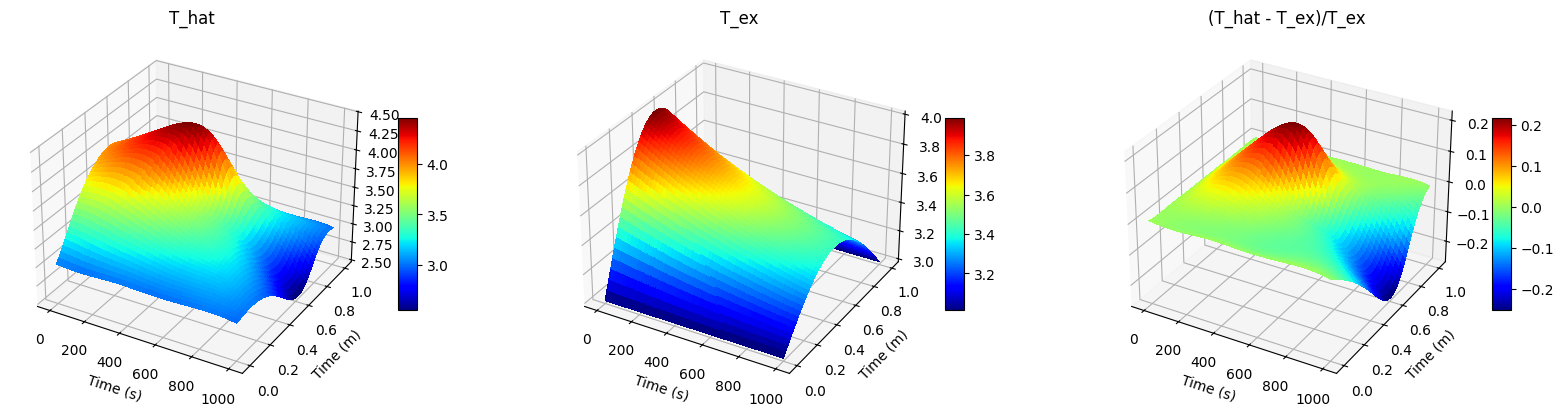

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5), subplot_kw=dict(projection='3d'))
ax = axs[0]
surf = ax.plot_surface(ms_t, ms_x, ms_Tpred, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('T_hat')
ax = axs[1]
surf = ax.plot_surface(ms_t, ms_x, ms_Tex, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('T_ex')
ax = axs[2]
surf = ax.plot_surface(ms_t, ms_x, (ms_Tpred-ms_Tex)/ms_Tex, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Time (m)')
ax.set_title('(T_hat - T_ex)/T_ex')
plt.show()

## Loss landscape

In [ ]:
def flatten_params(model):
    return torch.cat([p.detach().flatten() for p in model.parameters()])

def set_params_from_vector(model, vec):
    pointer = 0
    for p in model.parameters():
        if p.requires_grad:
            numel = p.numel()
            p.data.copy_(vec[pointer:pointer + numel].view_as(p))
            pointer += numel

def random_direction_like(model):
    return torch.cat([torch.randn_like(p).flatten() for p in model.parameters()])

def normalize(vec):
    return vec / vec.norm()

In [ ]:
def plot_loss_landscape(model, datasets, theta_0, d1, d2, range_val=1.0, steps=50):
    loss_fn = nn.MSELoss()
    alphas = np.linspace(-range_val, range_val, steps)
    betas = np.linspace(-range_val, range_val, steps)
    losses = np.zeros((steps, steps))

    for i, alpha in enumerate(alphas):
        for j, beta in enumerate(betas):
            theta = theta_0 + alpha * d1 + beta * d2
            set_params_from_vector(model, theta)

            # Calculate loss
            loss_list = []
            for tag in tags:
                X_data = (datasets[tag][:][0]).to(device)
                y_data = (datasets[tag][:][1]).to(device)
                if tag=='Domain':
                    X_data.requires_grad = True
                    T = model(X_data)
                    y_hat = model.internalEnergyBalanceResidue(X_data, T)
                    loss = loss_fn(y_hat, y_data)
                    loss_list.append(loss)

                else:
                    T = model(X_data)
                    loss = loss_fn(T, y_data)
                    loss_list.append(loss)

            loss = sum(loss_list)
            losses[i, j] = loss

    # Plotting
    A, B = np.meshgrid(alphas, betas)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(A, B, losses, cmap='viridis')
    ax.set_xlabel('alpha')
    ax.set_ylabel('beta')
    ax.set_zlabel('Loss')
    plt.title("2D Loss Landscape")
    plt.show()

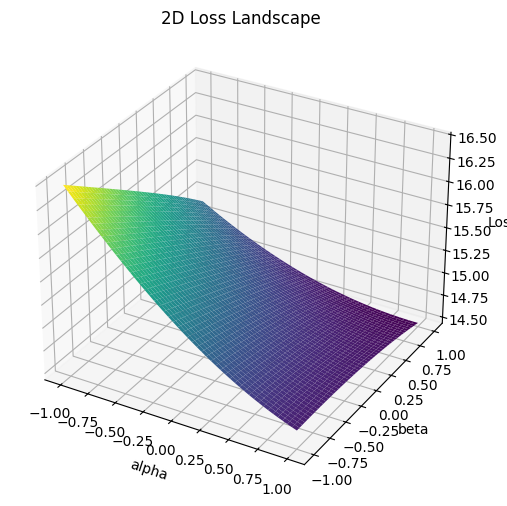

In [ ]:
    # Get trained parameter vector
    theta_0 = flatten_params(model)

    # Create two orthogonal directions
    d1 = normalize(random_direction_like(model))
    r = random_direction_like(model)
    d2 = normalize(r - torch.dot(r, d1) * d1)  # Gram-Schmidt

    # Plot the loss landscape
    plot_loss_landscape(model, datasets, theta_0, d1, d2, range_val=1.0, steps=50)